<center><p float="center">
  <img src="https://upload.wikimedia.org/wikipedia/commons/e/e9/4_RGB_McCombs_School_Brand_Branded.png" width="300" height="100"/>
  <img src="https://mma.prnewswire.com/media/1458111/Great_Learning_Logo.jpg?p=facebook" width="200" height="100"/>
</p></center>

<h1><center><font size=10>Artificial Intelligence and Machine Learning</center></font></h1>



<center> <font size=6> Project Python Foundations: FoodHub Data Analysis

<center><img src="https://www.netsolutions.com/wp-content/uploads/2022/10/essential-features-of-building-an-on-demand-food-ordering-app.jpg" width="720"></center>


### Context

The number of restaurants in New York is increasing day by day. Lots of students and busy professionals rely on those restaurants due to their hectic lifestyles. Online food delivery service is a great option for them. It provides them with good food from their favorite restaurants. A food aggregator company FoodHub offers access to multiple restaurants through a single smartphone app.

The app allows the restaurants to receive a direct online order from a customer. The app assigns a delivery person from the company to pick up the order after it is confirmed by the restaurant. The delivery person then uses the map to reach the restaurant and waits for the food package. Once the food package is handed over to the delivery person, he/she confirms the pick-up in the app and travels to the customer's location to deliver the food. The delivery person confirms the drop-off in the app after delivering the food package to the customer. The customer can rate the order in the app. The food aggregator earns money by collecting a fixed margin of the delivery order from the restaurants.

### Objective

The food aggregator company has stored the data of the different orders made by the registered customers in their online portal. They want to analyze the data to get a fair idea about the demand of different restaurants which will help them in enhancing their customer experience. Suppose you are hired as a Data Scientist in this company and the Data Science team has shared some of the key questions that need to be answered. Perform the data analysis to find answers to these questions that will help the company to improve the business.

### Data Description

The data contains the different data related to a food order. The detailed data dictionary is given below.

### Data Dictionary

* order_id: Unique ID of the order
* customer_id: ID of the customer who ordered the food
* restaurant_name: Name of the restaurant
* cuisine_type: Cuisine ordered by the customer
* cost_of_the_order: Cost of the order
* day_of_the_week: Indicates whether the order is placed on a weekday or weekend (The weekday is from Monday to Friday and the weekend is Saturday and Sunday)
* rating: Rating given by the customer out of 5
* food_preparation_time: Time (in minutes) taken by the restaurant to prepare the food. This is calculated by taking the difference between the timestamps of the restaurant's order confirmation and the delivery person's pick-up confirmation.
* delivery_time: Time (in minutes) taken by the delivery person to deliver the food package. This is calculated by taking the difference between the timestamps of the delivery person's pick-up confirmation and drop-off information

### Let us start by importing the required libraries

In [129]:
# Installing the libraries with the specified version.
!pip install numpy==2.0.2 pandas==2.2.2 matplotlib==3.10.0 seaborn==0.13.2 -q --user

**Note**:
- After running the above cell, kindly restart the runtime (for Google Colab) or notebook kernel (for Jupyter Notebook), and run all cells sequentially from the next cell.
- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in ***this notebook***.

In [130]:
# import libraries for data manipulation
import numpy as np
import pandas as pd

# import libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

### Understanding the structure of the data

In [131]:
# uncomment and run the below code snippets if the dataset is present in the Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [132]:
import pandas as pd
# Write your code here to read the data
# Reading datasets by using read_csv from pandas package
path='/content/drive/MyDrive/ColabNotebooks/Project1 - Foodhub/'
print(path)
df_food = pd.read_csv(path+"foodhub_order.csv")

/content/drive/MyDrive/ColabNotebooks/Project1 - Foodhub/


In [133]:
# Write your code here to view the first 5 rows
df_food.head()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24


### **Question 1:** How many rows and columns are present in the data? [0.5 mark]

In [134]:
# Write your code here
df_food.shape

(1898, 9)

#### Observations:
There are 1898 rows and 9 coloumns

### **Question 2:** What are the datatypes of the different columns in the dataset? (The info() function can be used) [0.5 mark]

In [135]:
# Write your code here
df_food.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1898 non-null   int64  
 1   customer_id            1898 non-null   int64  
 2   restaurant_name        1898 non-null   object 
 3   cuisine_type           1898 non-null   object 
 4   cost_of_the_order      1898 non-null   float64
 5   day_of_the_week        1898 non-null   object 
 6   rating                 1898 non-null   object 
 7   food_preparation_time  1898 non-null   int64  
 8   delivery_time          1898 non-null   int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 133.6+ KB


#### Observations:
There are 9 columns of which 1 float, 4 int and 4 object types.
Rating - is object which can be coverted into numeric value.
High level shows there are no missing values from this report atleast as non-null count is same as row count.

### **Question 3:** Are there any missing values in the data? If yes, treat them using an appropriate method. [1 mark]

In [136]:
# Write your code here
df_food.isnull().sum()

,0
order_id,0
customer_id,0
restaurant_name,0
cuisine_type,0
cost_of_the_order,0
day_of_the_week,0
rating,0
food_preparation_time,0
delivery_time,0


#### Observations:
there are not obvious NULL values which shows up in isnull().sum() but still need to do deeper analysis for understanding all are valid values or not.

### **Question 4:** Check the statistical summary of the data. What is the minimum, average, and maximum time it takes for food to be prepared once an order is placed? [2 marks]

In [137]:
# Write your code here
df_food.describe()

,order_id,customer_id,cost_of_the_order,food_preparation_time,delivery_time
count,1.898000e+03,1898.000000,1898.000000,1898.000000,1898.000000
mean,1.477496e+06,171168.478398,16.498851,27.371970,24.161749
std,5.480497e+02,113698.139743,7.483812,4.632481,4.972637
min,1.476547e+06,1311.000000,4.470000,20.000000,15.000000
25%,1.477021e+06,77787.750000,12.080000,23.000000,20.000000
50%,1.477496e+06,128600.000000,14.140000,27.000000,25.000000
75%,1.477970e+06,270525.000000,22.297500,31.000000,28.000000
max,1.478444e+06,405334.000000,35.410000,35.000000,33.000000


#### Observations:
All numeric values describe info suggests,
- Average cost_of_order is 16.49$ & prices range from Min 4.47$ to Max of 35.41$
- Average Food_preparation_time is 27.37 & Times vary from Min 20 to Max of 35.
- Average Delivery_time is 24.16 & Times vary from Min 15 to Max of 33.
- Insights into Order_id and Customer_id are not useful as they are just ids

### **Question 5:** How many orders are not rated? [1 mark]

In [138]:
# Write the code here
#check unique values
df_food['rating'].unique()
#check how many non integers (Not given)
no_ratings = df_food[df_food['rating']=='Not given'].shape[0]
print(no_ratings,"users didnt give ratings")

736 users didnt give ratings


#### Observations:
Initial data in object/string format shows NO missing values but while checking deeply into data shows "Not given" value which is equivalent to numerical Missing values.
So, converting this data into Numeric and counting shows 763 missing values.

### Exploratory Data Analysis (EDA)

### Univariate Analysis

### **Question 6:** Explore all the variables and provide observations on their distributions. (Generally, histograms, boxplots, countplots, etc. are used for univariate exploration.) [9 marks]

Number of customers 1200
Number of orders 1898
Number of Restaurants 178
Number of cuisines 14
day_of_the_week values ['Weekend' 'Weekday']


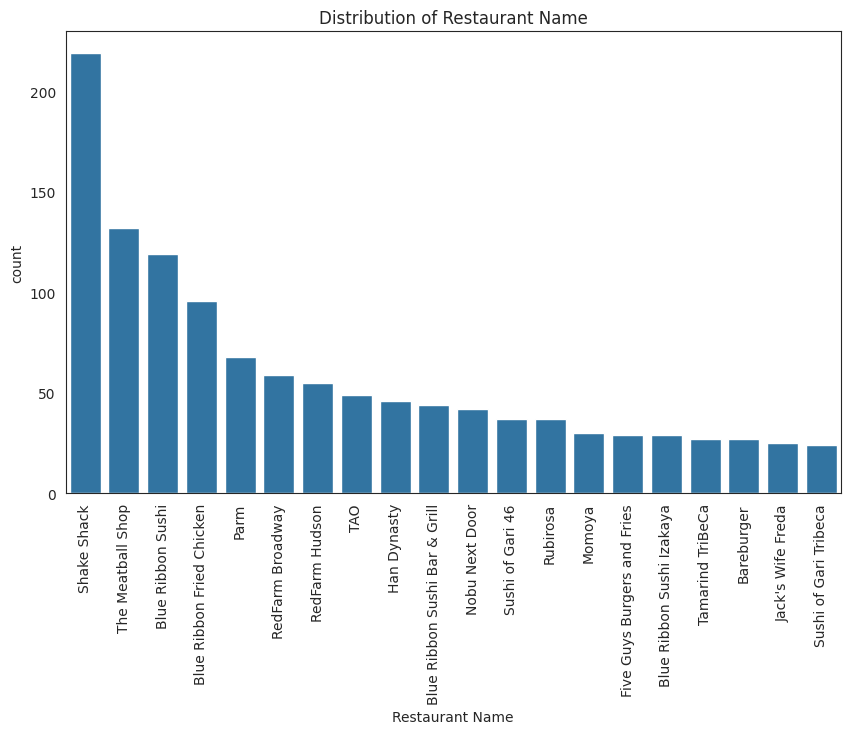

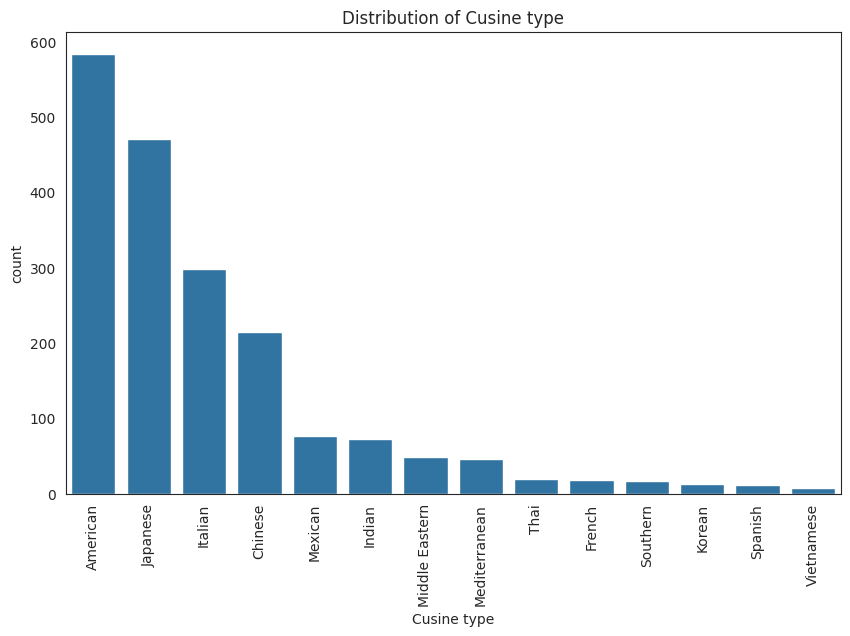

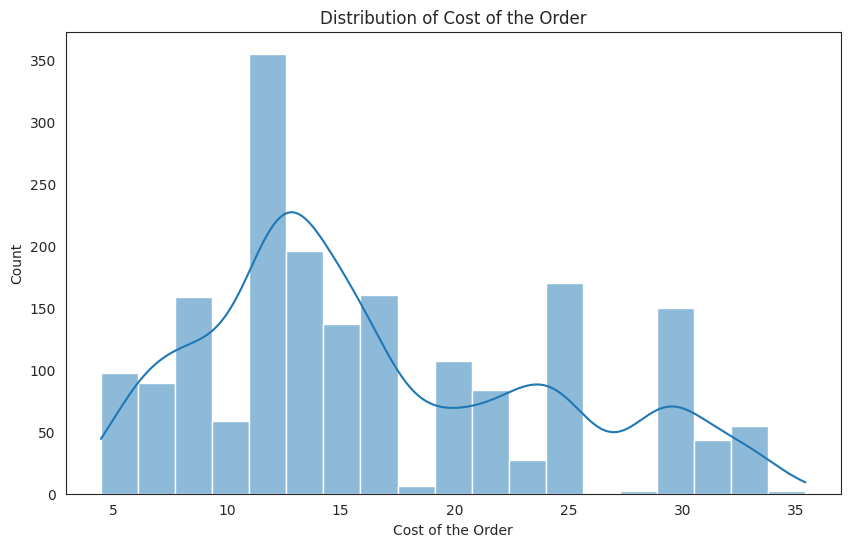

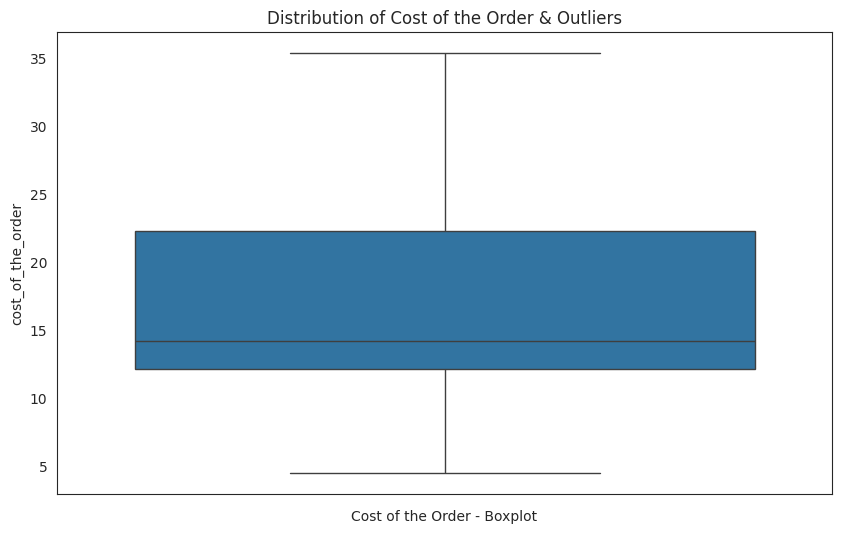

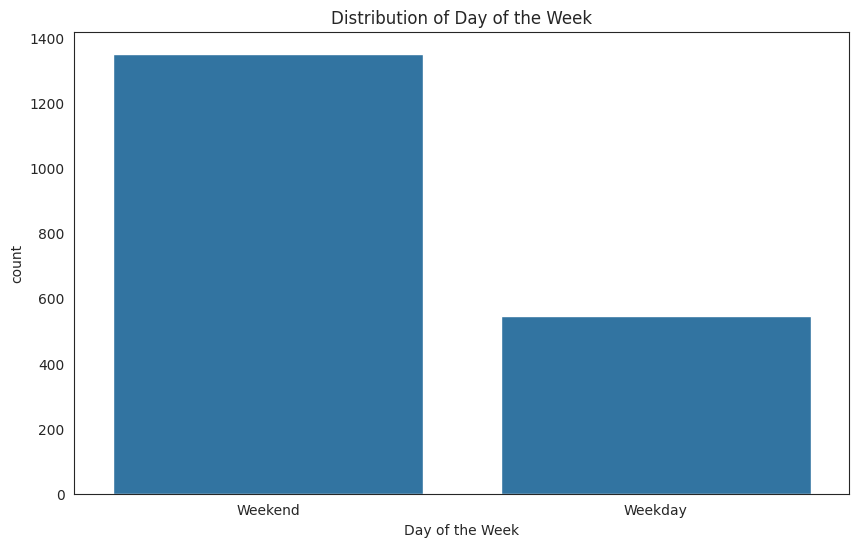

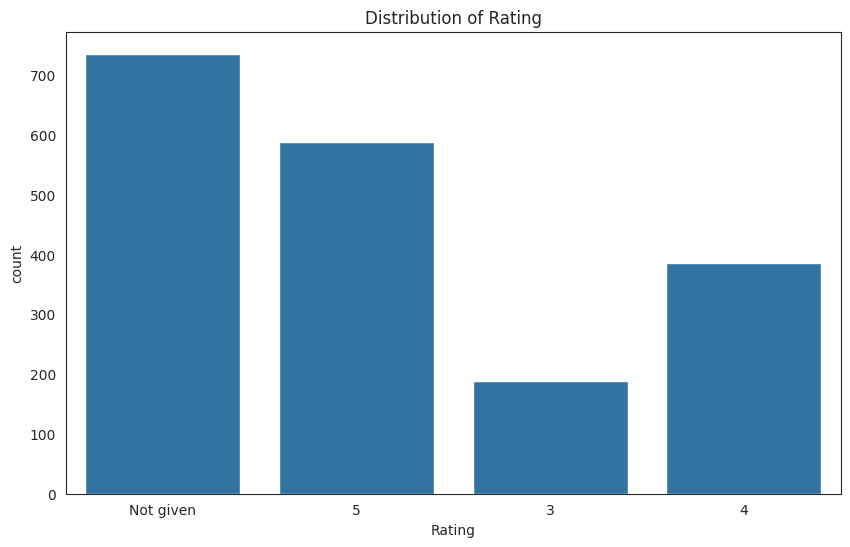

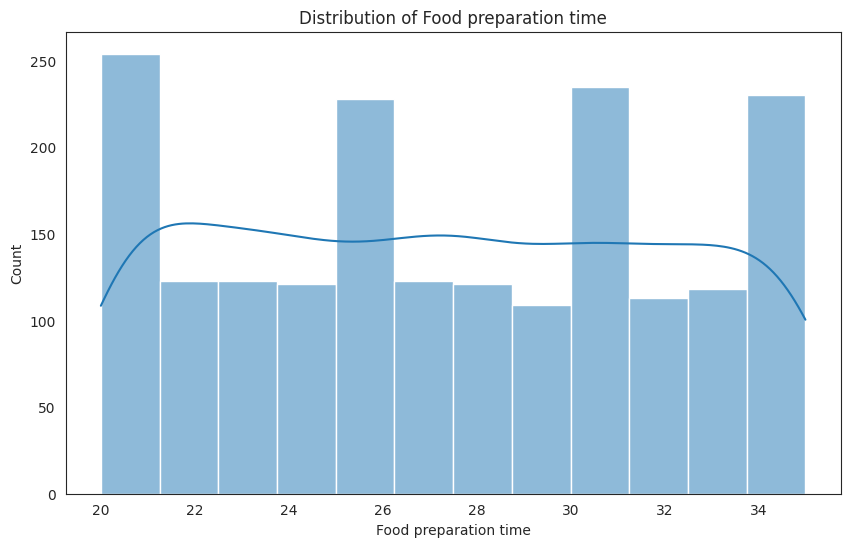

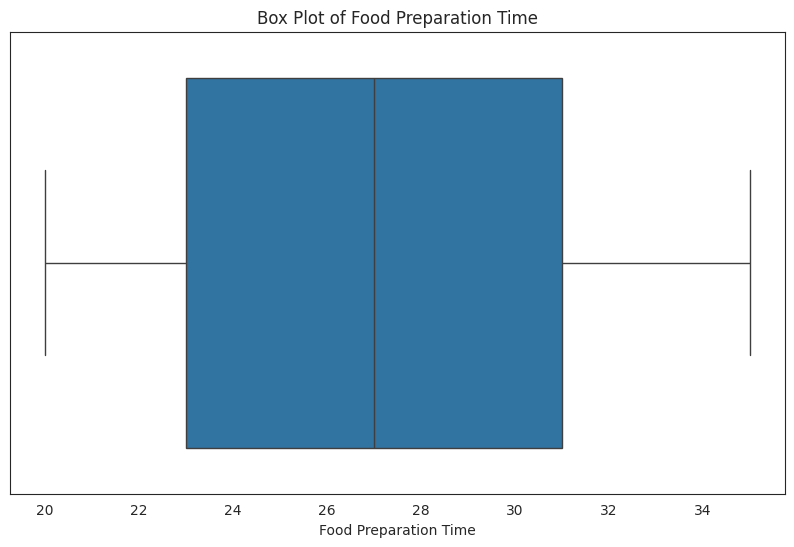

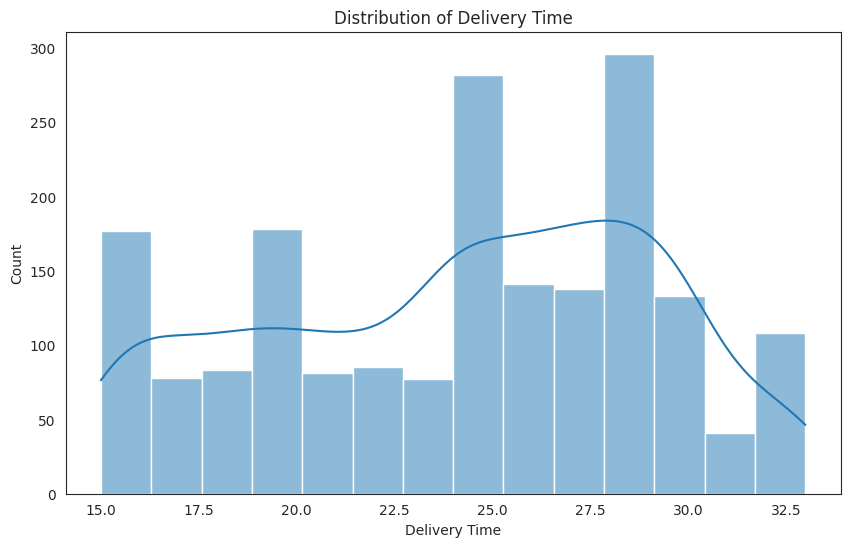

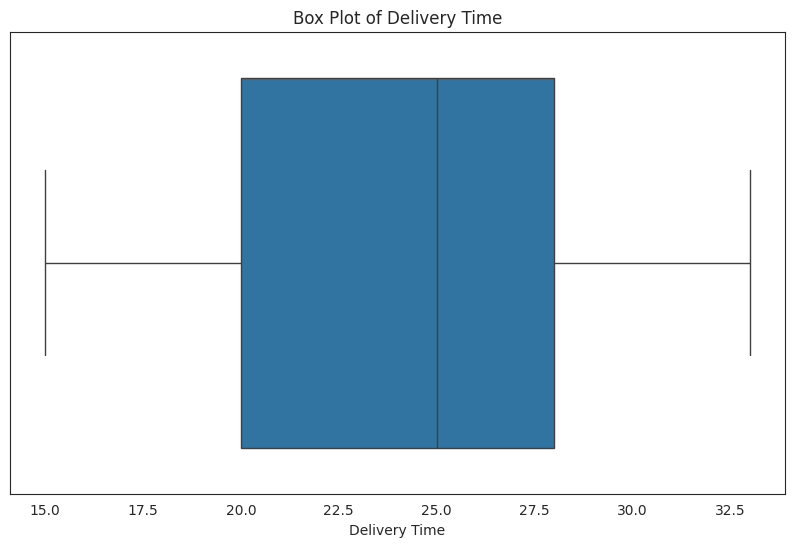

In [139]:
# Write the code here

#Explore all the variables and provide observations on their distributions. (Generally, histograms, boxplots, countplots, etc. are used for univariate exploration.)

#order_id & customer_id doesn't mean anything
#check how many customers
print("Number of customers",df_food['customer_id'].nunique())

#check how many orders
print("Number of orders",df_food['order_id'].nunique())

#restaurant_name - categorical - countplt for top 20 as too many restaurants
print("Number of Restaurants",df_food['restaurant_name'].nunique())
plt.figure(figsize=(10 , 6));
sns.countplot(data=df_food, x='restaurant_name',
              order=df_food['restaurant_name'].value_counts().iloc[:20].index);
plt.xticks( rotation=90);
plt.title('Distribution of Restaurant Name');
plt.xlabel('Restaurant Name');

#cuisine_type - categorical - countplot
print("Number of cuisines",df_food['cuisine_type'].nunique())
plt.figure(figsize=(10 , 6));
sns.countplot(data=df_food, x='cuisine_type',
              order=df_food['cuisine_type'].value_counts().index);
plt.xticks( rotation=90);
plt.title('Distribution of Cusine type')
plt.xlabel('Cusine type');

# Cost of the order - Numeric - Histogram with KDE
plt.figure(figsize=(10, 6));
sns.histplot(df_food['cost_of_the_order'], kde=True);
plt.title('Distribution of Cost of the Order');
plt.xlabel('Cost of the Order');

# check box plot for any outliers
plt.figure(figsize=(10, 6));
sns.boxplot(df_food['cost_of_the_order']);
plt.title('Distribution of Cost of the Order & Outliers');
plt.xlabel('Cost of the Order - Boxplot');

# day_of_the_week - categorical - countplot
print("day_of_the_week values", df_food['day_of_the_week'].unique())
plt.figure(figsize=(10, 6));
sns.countplot(data=df_food,x='day_of_the_week');
plt.title('Distribution of Day of the Week');
plt.xlabel('Day of the Week');

#Ratings - categorical - histplot
plt.figure(figsize=(10, 6));
sns.countplot(data=df_food, x='rating')
plt.title('Distribution of Rating');
plt.xlabel('Rating');

#Food preparation time - Numeric - Histplot
plt.figure(figsize=(10, 6));
sns.histplot(df_food['food_preparation_time'], kde=True);
plt.title('Distribution of Food preparation time');
plt.xlabel('Food preparation time');

#Food preparation time box plot to check outliers
plt.figure(figsize=(10, 6));
sns.boxplot(x=df_food['food_preparation_time']);
plt.title('Box Plot of Food Preparation Time');
plt.xlabel('Food Preparation Time');

#Delivery time - Numeric - histplot
plt.figure(figsize=(10, 6));
sns.histplot(x=df_food['delivery_time'], kde=True);
plt.title('Distribution of Delivery Time');
plt.xlabel('Delivery Time');

#Delivery time box plot to check outliers
plt.figure(figsize=(10, 6));
sns.boxplot(x=df_food['delivery_time']);
plt.title('Box Plot of Delivery Time');
plt.xlabel('Delivery Time');


#### Observations:

Based on Analysis of each columns,

1. Identifiers: The order_id and customer_id columns serve as unique identifiers for transactions and users;
There are 1200 unique customers who made 1898 orders on the platform.

2. Restaurant Popularity: The distribution of orders across restaurants is heavily right-skewed, indicating that while many restaurants receive only a few orders, a small group—led by Shake Shack—dominates the platform's volume.

3. Cuisine Preferences: American and Japanese cuisines are the most popular choices among customers, whereas Vietnamese cuisine has the lowest representation in the dataset.

4. Order Costs: The majority of orders are priced below $20, and the distribution is right-skewed, showing that higher-priced gourmet orders are less frequent than budget-friendly options.

5. Weekly Demand: There is a significant surge in demand during the weekends, with order volumes nearly doubling compared to weekday totals.

6. Customer Ratings: The rating distribution is skewed toward high satisfaction; no ratings fall below 3, and the most frequent score given by customers is a 5.

7. Kitchen Efficiency: Food preparation time is relatively uniform, ranging from 20 to 34 minutes, with no significant peaks or "slow" preparation categories.

8. Delivery Logistics: Delivery times range from 15 to 32 minutes, with a high concentration of orders being completed around the 20-minute mark.





### **Question 7**: Which are the top 5 restaurants in terms of the number of orders received? [1 mark]

In [140]:
# Write the code here
df_food['restaurant_name'].value_counts().head(5)


,count
restaurant_name,
Shake Shack,219
The Meatball Shop,132
Blue Ribbon Sushi,119
Blue Ribbon Fried Chicken,96
Parm,68


#### Observations:
Top 5 restaurents are as above and #1 being Shake Shack and 5th being Parm.

### **Question 8**: Which is the most popular cuisine on weekends? [1 mark]

In [141]:
# Write the code here
popular_wknd_cusine = df_food[df_food['day_of_the_week'] == 'Weekend']
popular_wknd_cusine['cuisine_type'].value_counts().head(1)

,count
cuisine_type,
American,415


#### Observations:
There are 415 orders on weekends for American cuisine

### **Question 9**: What percentage of the orders cost more than 20 dollars? [2 marks]

In [142]:
# Write the code here
df_higherthan_20 = df_food[df_food['cost_of_the_order'] > 20].shape[0]/df_food.shape[0]*100
print(f"Percentage of orders above 20$ are of", round(df_higherthan_20, 2),"%")



Percentage of orders above 20$ are of 29.24 %


#### Observations:
there are 29.24 % of the orders are of Cost greater than $20.

### **Question 10**: What is the mean order delivery time? [1 mark]

In [143]:
# Write the code here
print("Average delivery time for orders is ",df_food['delivery_time'].mean().round(2),"minutes")

Average delivery time for orders is  24.16 minutes


#### Observations:
Average time for Delivery is around 24.16 min

### **Question 11:** The company has decided to give 20% discount vouchers to the top 3 most frequent customers. Find the IDs of these customers and the number of orders they placed. [1 mark]

In [144]:
# Write the code here

df_food['customer_id'].value_counts().head(3)

,count
customer_id,
52832,13
47440,10
83287,9


#### Observations:
Top Customers did 13, 10, 9 orders

### Multivariate Analysis

### **Question 12**: Perform a multivariate analysis to explore relationships between the important variables in the dataset. (It is a good idea to explore relations between numerical variables as well as relations between numerical and categorical variables) [10 marks]


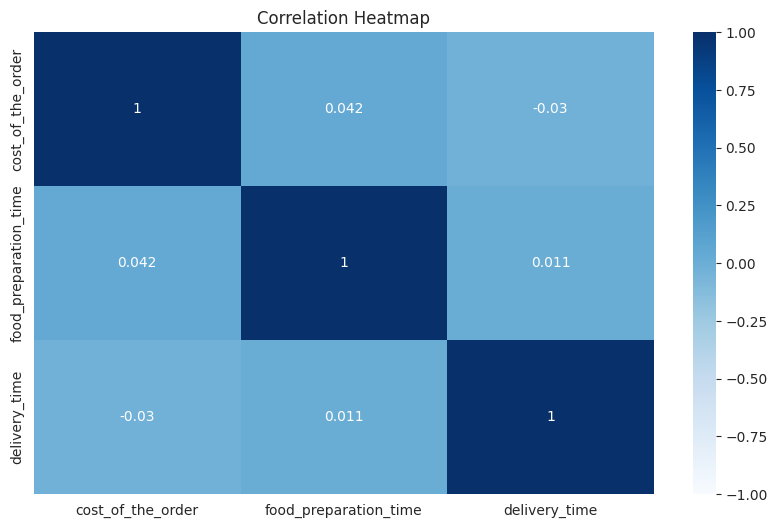

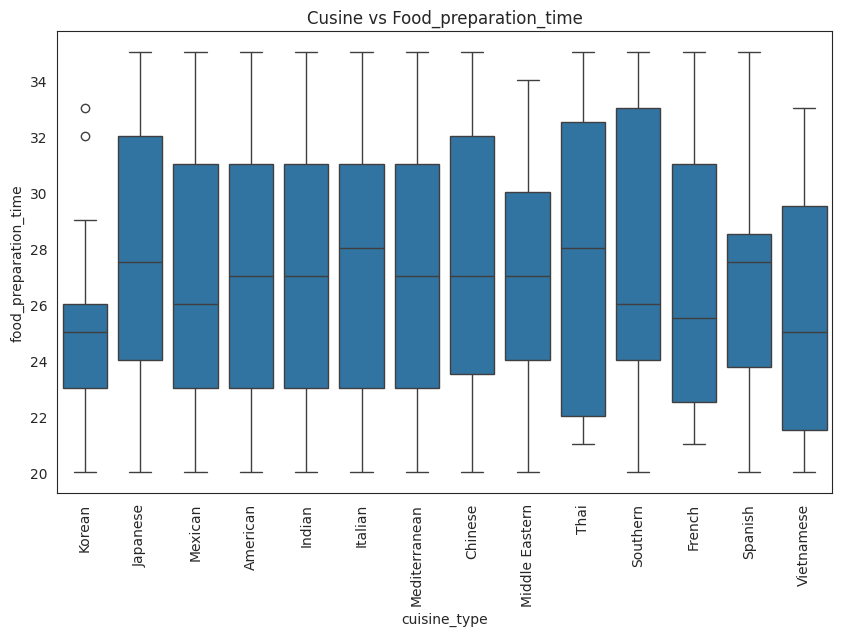

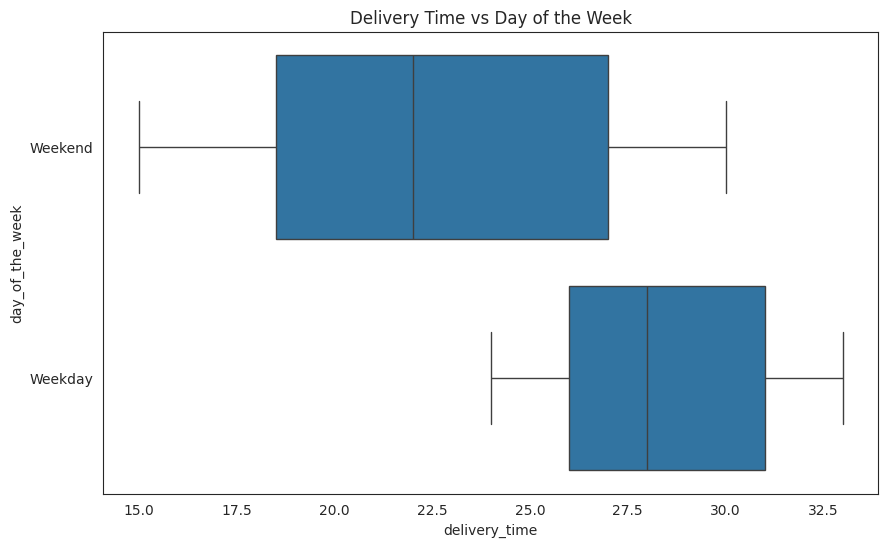

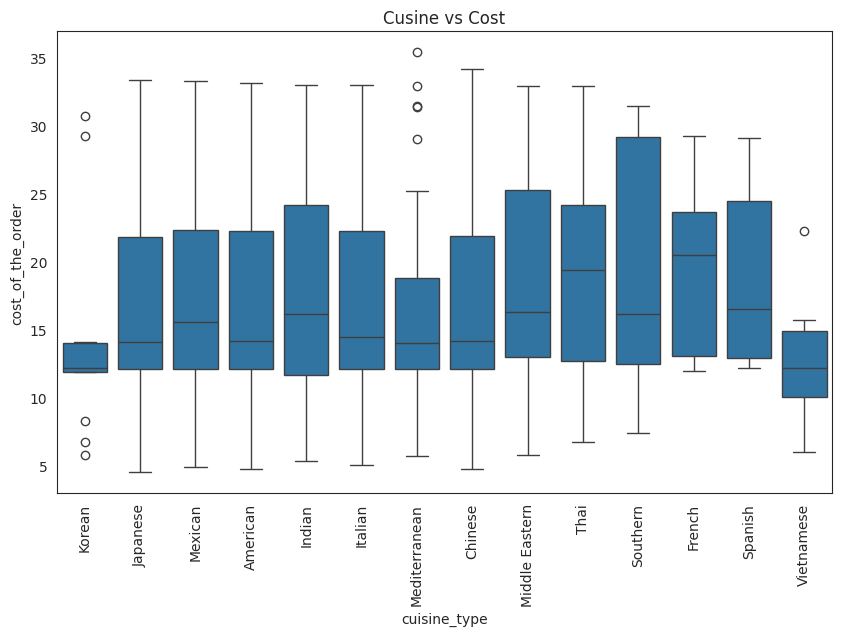

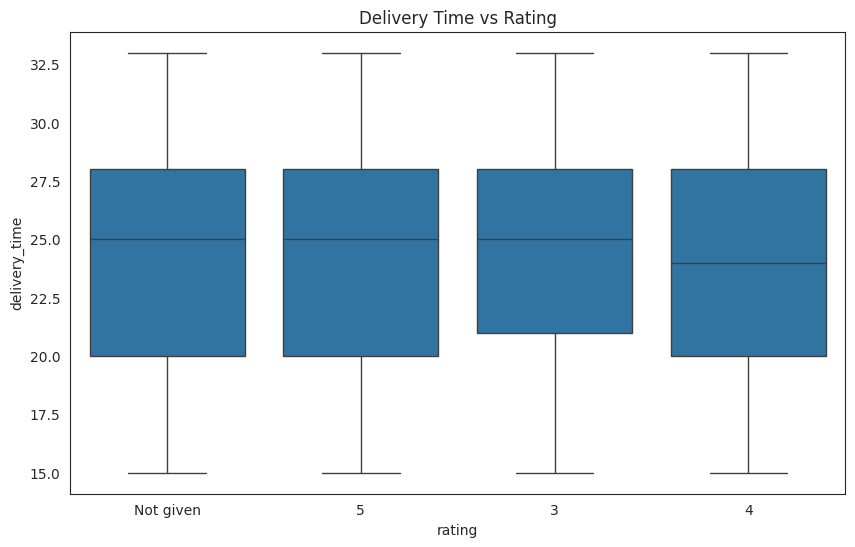

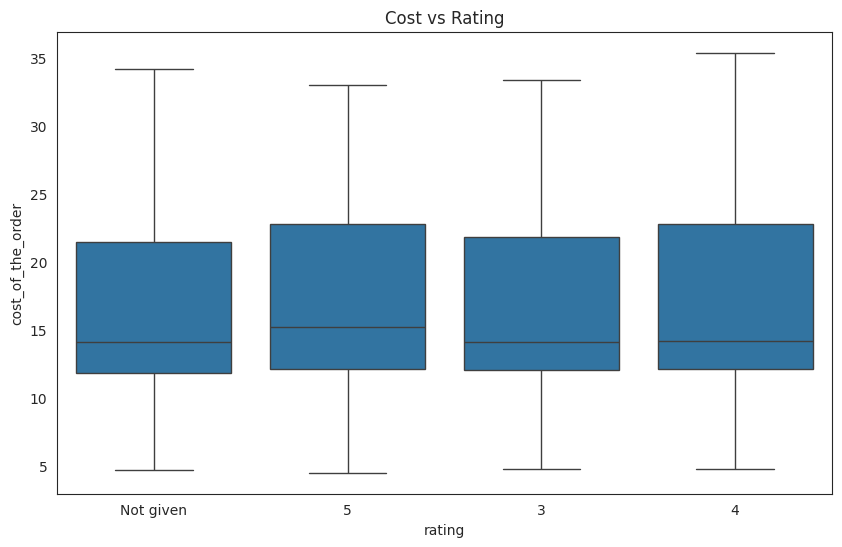

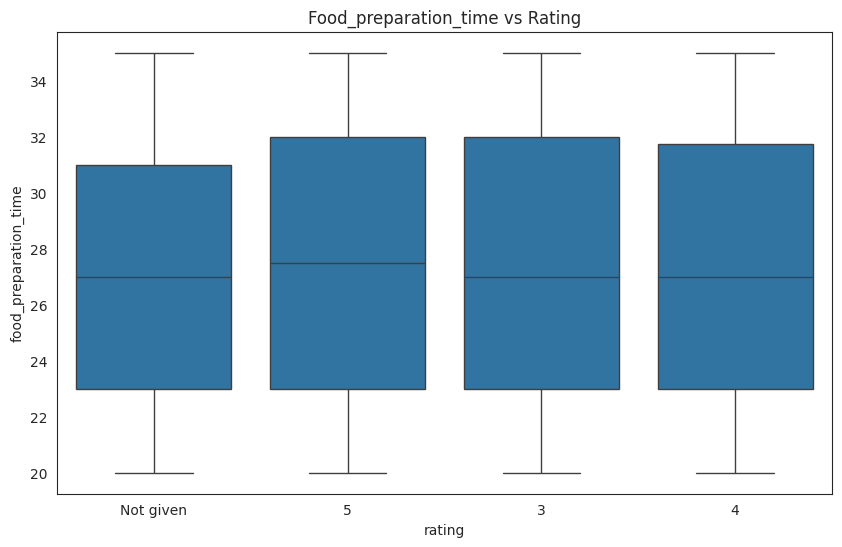

In [145]:
# Write the code here
# create a heatmap
df_num_variables = ['cost_of_the_order', 'food_preparation_time', 'delivery_time']
corr = df_food[df_num_variables].corr();
plt.figure(figsize=(10, 6));
sns.heatmap(corr, annot=True, vmin=-1, vmax=1, cmap='Blues');
plt.title('Correlation Heatmap');
plt.show();

# check which cuisine_type have high preparation time and low ratings
# check whcih cuisine_type havae high ratings and low preparation time
# possible recommendations - can prioiritze specific cuisine_type more
# categorical values relation - Box plot
plt.figure(figsize=(10, 6));
sns.boxplot(data=df_food, x='cuisine_type', y='food_preparation_time');
plt.xticks( rotation=90);
plt.title('Cusine vs Food_preparation_time');

# check delivery times vs ratings and how it is impacted for top 5 restaurants
# possible recommendations - Reduce delivery times of famous restaurants
# Numberical values - scatterplot
plt.figure(figsize=(10, 6));
sns.boxplot(data=df_food, x='delivery_time', y='day_of_the_week');
plt.title('Delivery Time vs Day of the Week');

# categorical values relation - Box plot
# check cost vs cuisine
plt.figure(figsize=(10, 6));
sns.boxplot(data=df_food, x='cuisine_type', y='cost_of_the_order');
plt.xticks( rotation=90);
plt.title('Cusine vs Cost');

# rating vs delivery_time
plt.figure(figsize=(10, 6));
sns.boxplot(data=df_food, x='rating', y='delivery_time');
plt.title('Delivery Time vs Rating');

# rating vs cost_of_the_order
plt.figure(figsize=(10, 6));
sns.boxplot(data=df_food, x='rating', y='cost_of_the_order');
plt.title('Cost vs Rating');

#rating vs food_preparation_time
plt.figure(figsize=(10, 6));
sns.boxplot(data=df_food, x='rating', y='food_preparation_time');
plt.title('Food_preparation_time vs Rating');



##Observations

1. Correlation Insights (Heatmap)
* "Price vs. Speed": There is almost zero correlation (near 0) between the cost of the order and the food preparation time. It proves that Food Preparation Time doesn't actually go up just because a meal is more expensive

* Independent Logistics: Similarly, delivery time is independent of the order cost. The logistics side of the business (driving) is completely decoupled from the kitchen side (cooking).

2. Cuisine vs. Time & Cost (Boxplots)
*  Most cuisines (American, Japanese, Italian) have a very similar preparation time distribution, usually ranging between 25 and 30 minutes. However, cuisines like French and Thai show a wider variance, suggesting their preparation is less standardized.

* The Premium Cuisines: French and Thai food tend to have higher median costs compared to others. Conversely, Korean and Vietnamese food are consistently the most budget-friendly options on the platform.


3. Delivery Performance (Day of the Week)
* The Weekend Advantage: The delivery time distribution for weekends is significantly "tighter" and lower than weekdays. Even with higher order volumes on weekends, our couriers are faster, likely due to a lack of weekday commuter traffic.


4. Rating Influencers
* The boxplot for Cost vs. Rating shows that higher-priced orders don't necessarily result in better ratings. A 5 dollar order is just as likely to get a "5-star" rating as a $30 order.

* The 60-Minute Threshold: In the Delivery Time vs. Rating plot, you can see a slight downward trend. As delivery time creeps toward the 30-minute mark (pushing the total time over 60), the frequency of lower ratings (3s) starts to increase.

### **Question 13:** The company wants to provide a promotional offer in the advertisement of the restaurants. The condition to get the offer is that the restaurants must have a rating count of more than 50 and the average rating should be greater than 4. Find the restaurants fulfilling the criteria to get the promotional offer. [3 marks]

In [146]:
# Write the code here

# Convert rating to numeric, turning 'Not given' into NaN (null)
df_food['rating'] = pd.to_numeric(df_food['rating'], errors='coerce')

# Calculate count (volume) and mean (quality) per restaurant
restaurant_stats = df_food.groupby('restaurant_name')['rating'].agg(['count', 'mean']).reset_index()

# Filter for the company's specific promotional criteria (>50 ratings and >4.0 average)
promo_restaurants = restaurant_stats[(restaurant_stats['count'] > 50) & (restaurant_stats['mean'] > 4)]

# Sort by rating in descending order to highlight top performers first
promo_restaurants.sort_values(by='mean', ascending=False).reset_index(drop=True)


,restaurant_name,count,mean
0,The Meatball Shop,84,4.511905
1,Blue Ribbon Fried Chicken,64,4.328125
2,Shake Shack,133,4.278195
3,Blue Ribbon Sushi,73,4.219178


#### Observations:
Only 4 restaurants qualify for the promotional offer: The Meatball Shop, Blue Ribbon Fried Chicken, Shake Shack, and Blue Ribbon Sushi.

### **Question 14:** The company charges the restaurant 25% on the orders having cost greater than 20 dollars and 15% on the orders having cost greater than 5 dollars. Find the net revenue generated by the company across all orders. [3 marks]

In [147]:
# Write the code here
# Define logic for tiered commission: 25% for >$20, 15% for >$5, and 0% otherwise
def calculate_revenue(cost):
    if cost > 20:
        return cost * 0.25
    elif cost > 5:
        return cost * 0.15
    else:
        return 0

# Create a new column to store the calculated revenue for each individual order
df_food['revenue'] = df_food['cost_of_the_order'].apply(calculate_revenue)

# Sum the new column to find the total net revenue across all orders
total_revenue = df_food['revenue'].sum()

print(f"The net revenue generated by the company across all orders is: ${round(total_revenue,2)}")


The net revenue generated by the company across all orders is: $6166.3


#### Observations:
The total net revenue generated is $6,166.30.

### **Question 15:** The company wants to analyze the total time required to deliver the food. What percentage of orders take more than 60 minutes to get delivered from the time the order is placed? (The food has to be prepared and then delivered.) [2 marks]

In [148]:
# Write the code here
# Sum prep and delivery times to get the total duration from order to doorstep
df_food['total_time'] = df_food['food_preparation_time'] + df_food['delivery_time']

#Identify orders exceeding the 60-minute threshold
orders_above_60 = df_food[df_food['total_time'] > 60].shape[0]

# Calculate the percentage of late orders relative to the total dataset size
percentage_above_60 = (orders_above_60 / df_food.shape[0]) * 100

#  Print the result rounded to 2 decimal places
print(f"Percentage of orders taking more than 60 minutes is: {round(percentage_above_60,2)}%")

Percentage of orders taking more than 60 minutes is: 10.54%


#### Observations:
Approximately 10.54% of all orders take longer than 60 minutes to reach the customer.

### **Question 16:** The company wants to analyze the delivery time of the orders on weekdays and weekends. How does the mean delivery time vary during weekdays and weekends? [2 marks]

In [149]:
# Write the code here
# Group by 'day_of_the_week' and calculate the mean of 'delivery_time'
mean_delivery_time = df_food.groupby('day_of_the_week')['delivery_time'].mean()

# Display the result rounded to 2 decimal places
print("Mean delivery time during weekdays and weekends:")
print(mean_delivery_time.round(2))

Mean delivery time during weekdays and weekends:
day_of_the_week
Weekday    28.34
Weekend    22.47
Name: delivery_time, dtype: float64


#### Observations:
Weekdays: Mean delivery time is 28.34 minutes.

Weekends: Mean delivery time is 22.47 minutes.

### Conclusion and Recommendations

### **Question 17:** What are your conclusions from the analysis? What recommendations would you like to share to help improve the business? (You can use cuisine type and feedback ratings to drive your business recommendations.) [6 marks]

### Conclusions:

1. The Weekend Engine: Our growth is heavily weekend-skewed, with nearly double the volume compared to weekdays. This is anchored by a few "powerhouse" restaurants like Shake Shack and a clear customer preference for American and Japanese cuisines.

2. The Revenue Sweet Spot: Our profitability relies on high-value orders. While only 29.24% of orders exceed $20, these are critical because they trigger the 25% commission bracket, significantly outpacing the 15% we earn on smaller orders.

3. The Weekday Bottleneck: There is a clear operational drag during the week. Deliveries are ~6 minutes slower on weekdays (28.34 min) than weekends (22.47 min), which likely explains why 10.5% of our orders are currently missing our 60-minute service window.

4. Rating Analysis: Data shows a large portion of our users, as 38.8% of orders have no rating. While the feedback we do have is positive, we need more data from this silent majority to catch potential issues early.

### Recommendations:

1.  Push the "Cart-to-20" Upsell: Since data shows  make a significantly higher commission (25% vs 15%) once an order hits $20, we should use "smart prompts" at checkout to suggest a side or drink when a user is just a few dollars short; this would directly boost our net revenue by shifting thousands of orders into that higher profit bracket.

2. Fix the Weekday Delivery Lag: We found that weekday deliveries are nearly 6 minutes slower than weekends, which is likely causing that 10.5% of "late" orders. By offering a small "speed bonus" to couriers during weekday lunch and dinner rushes, we can bring those times down to weekend levels and stop customers from quitting the app due to long wait times.

3. Double Down on the "Elite Four" Restaurants: Data shows a very small group of restaurants that have both high volume and high ratings (like Shake Shack and The Meatball Shop). We should feature these as "Top Picks" for every new user's first order, ensuring their first experience is perfect and drastically increasing the chance they become a loyal, long-term customer.

4. User Rating Not Given: With nearly 40% of orders having no rating, missing a lot of feedback. Implementing a tiny incentive—like 50 loyalty points for a 2-second rating—will give us the data we need to catch struggling restaurants before they ruin the experience for other users.

5. Diversify via Cuisine-Based Promos: You noticed that cuisines like Vietnamese and Korean have very low volume despite being affordable. Running targeted "Cuisine Discovery" weeks with lower delivery fees can help us grow beyond just American and Japanese food, making the platform the go-to app for any type of craving.

6. Tackle Preparation Bottlenecks: Since roughly 1 in 10 orders takes over an hour, we should provide real-time performance dashboards to the restaurants you identified with long prep times; this helps them optimize their kitchens and keeps our delivery partners moving faster, allowing them to complete more trips per shift.

# Author: Ravi Kanth Ventrapragada | Date: April 2026

---